# Model testing and validation

# Imports

In [1]:
import joblib
import scipy.sparse as sp
import pandas as pd
from sklearn.metrics import classification_report

## Import models

In [2]:
tfidf = joblib.load('csv/tfidf_dump.pkl')
model = joblib.load('csv/sentiment_model.pkl')

X_test  = sp.load_npz('csv/X_test.npz')
y_test  = pd.read_csv('csv/y_test.csv')['Sentiment']

# Testing

In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     99973
    Positive       1.00      1.00      1.00    100027

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



This model has an *supposedly* has an accuracy of 100% with a count of 200,000 rows available used for support.

# Visualisation

This is a confusion matrix, which is able to visualise the accuracy of the a model, and how it performed in the test. 

Using the testing data, we can use `sklearn`s confusion_matrix function to create a heatmap and plot it. 

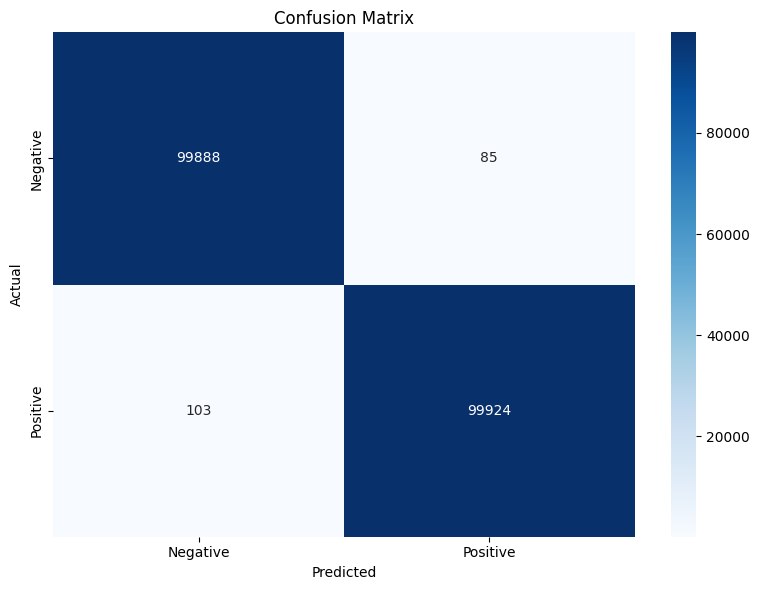

In [4]:
# disclaimer: block was gen by ai
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Observations

The model looks to have difficulty differentiating between neutral and positive/negative data. Based on our initial analysis in Step 0 of the pipeline, we have combined `Neutral` and `Irrelevant` sentiments together (total: 30893), which creates more data. With more data creates a more error 

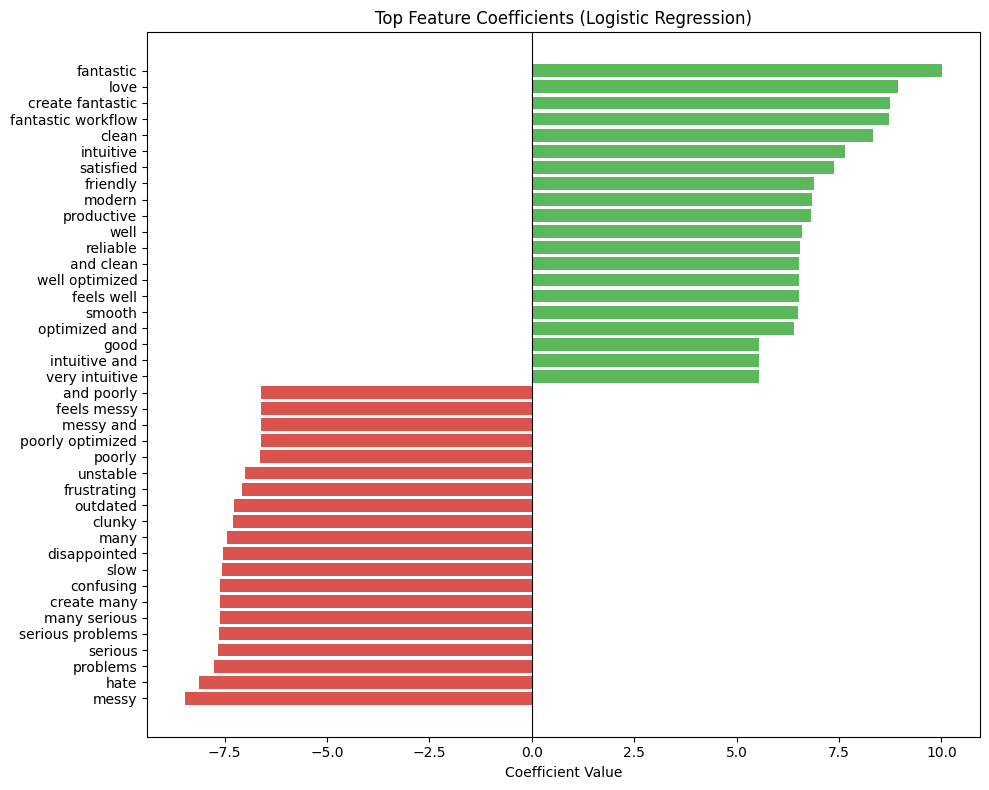

In [5]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_n = 20
top_pos_idx = np.argsort(coefficients)[-top_n:]
top_neg_idx = np.argsort(coefficients)[:top_n]
indices = np.concatenate([top_neg_idx, top_pos_idx])
values = coefficients[indices]
labels = feature_names[indices]

colors = ['#d9534f' if v < 0 else '#5cb85c' for v in values]

plt.figure(figsize=(10, 8))
plt.barh(labels, values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

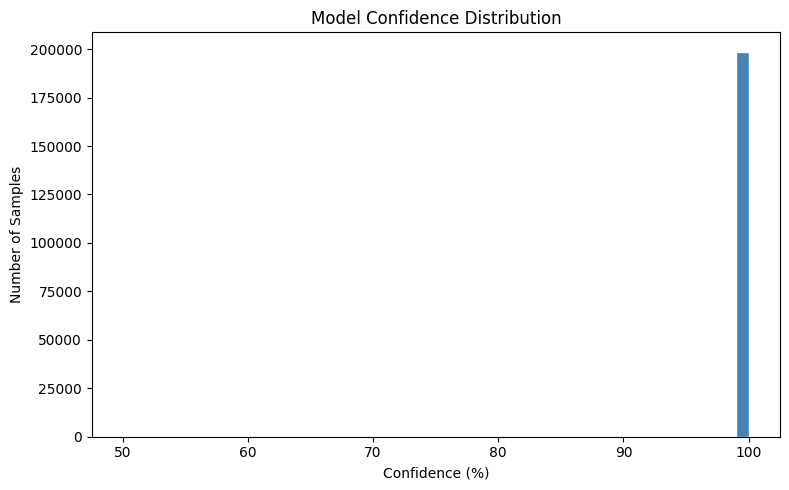

In [6]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1) * 100

plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=50, color='steelblue', edgecolor='white')
plt.title('Model Confidence Distribution')
plt.xlabel('Confidence (%)')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()


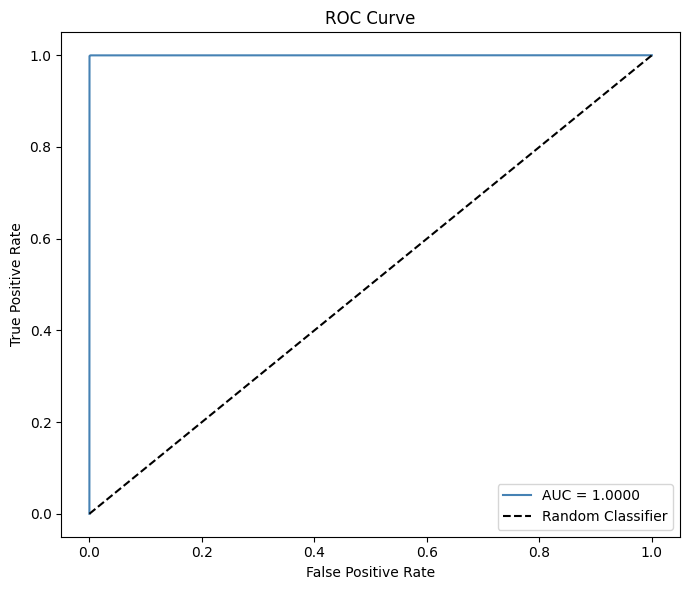

In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

[99.8581243  99.92425503 99.95970053 99.97705512 99.98357859]


(array([ 31.,  33.,  26.,  37.,  26.,  39.,  31.,  30.,  30.,  24.,  30.,
         34.,  39.,  28.,  29.,  37.,  22.,  33.,  28.,  33.,  28.,  21.,
         28.,  19.,  23.,  21.,  23.,  25.,  19.,  12.,  14.,  11.,  11.,
         11.,  11.,   7.,   9.,   5.,   8.,   5.,   3.,   2.,   3.,   1.,
          0.,   2.,   0.,   0.,  16., 307.]),
 array([50.05139008, 51.03035778, 52.00932548, 52.98829318, 53.96726089,
        54.94622859, 55.92519629, 56.90416399, 57.88313169, 58.86209939,
        59.84106709, 60.8200348 , 61.7990025 , 62.7779702 , 63.7569379 ,
        64.7359056 , 65.7148733 , 66.693841  , 67.67280871, 68.65177641,
        69.63074411, 70.60971181, 71.58867951, 72.56764721, 73.54661491,
        74.52558262, 75.50455032, 76.48351802, 77.46248572, 78.44145342,
        79.42042112, 80.39938882, 81.37835653, 82.35732423, 83.33629193,
        84.31525963, 85.29422733, 86.27319503, 87.25216273, 88.23113044,
        89.21009814, 90.18906584, 91.16803354, 92.14700124, 93.12596894,
 

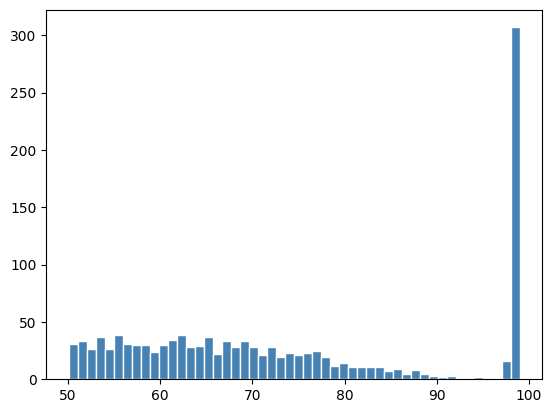

In [10]:
print(np.percentile(confidence, [25, 50, 75, 90, 95]))
# Zoom into the interesting range
plt.hist(confidence[confidence < 99], bins=50, color='steelblue', edgecolor='white')